In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import json

def age_to_group(age):

    if age < 18:
        return "0-18"
    elif age <= 40:
        return "18-40"
    elif age <= 60:
        return "40-60"
    elif age <= 80:
        return "60-80"
    else:
        return "80+"

def stratify_group(row):
    # Combine demographic and label attributes into a single stratification key
    attrs = [
        str(row["gender"]).strip().upper() if pd.notna(row["gender"]) else "UNK",
        str(row["ethnicity"]).strip().upper() if pd.notna(row["ethnicity"]) else "UNK",
        str(row['age_group']).strip().upper() if pd.notna(row["age_group"]) else "UNK",
    ]

    return "_".join(attrs)

source_dir = Path("/home/vito/ibrahimm/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr-jpg/2.0.0/")
raw_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data")
resize_size = 512

original_metadata_df = pd.read_csv(raw_dir / "mimic-cxr-2.0.0-metadata-with-demographics.csv")
original_metadata_df['age_group'] = original_metadata_df['anchor_age'].apply(age_to_group)

chexpert_df = pd.read_csv(raw_dir / "mimic-cxr-2.0.0-chexpert.csv")
impressions_df = pd.read_csv("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/sections/mimic_cxr_sectioned.csv")
impressions_df['study_id'] = impressions_df['study'].str.replace('s', '').astype(int)
merged_df = pd.merge(original_metadata_df, chexpert_df, on=["subject_id", "study_id"], how="inner")
# roentgen-v2 use impressions
all_df = pd.merge(impressions_df, merged_df, on="study_id", how="inner")
all_df['image'] = all_df.apply(
    lambda row: f"{raw_dir}/files/p{str(int(row['subject_id']))[:2]}/p{str(int(row['subject_id']))}/"
    f"s{int(row['study_id'])}/{row['dicom_id']}.jpg", 
    axis=1)
all_df['folder'] = all_df['subject_id'].apply(lambda x: str(x)[:2])
all_df.shape


(377024, 37)

In [2]:
# --- Filter and prepare PA_data as before ---
PA_data = all_df[all_df['ViewPosition'] == 'PA']
print('Data after excluding non-PA studies:', PA_data.shape)
PA_data = PA_data[PA_data['impression'].notna()]
print('Data after excluding studies with no impression:', PA_data.shape)
ethnicity_map = {
    'WHITE': 'White',
    'HISPANIC/LATINO': 'Hispanic', 
    'BLACK/AFRICAN AMERICAN': 'Black',
    'ASIAN': 'Asian'
}
PA_data['ethnicity'] = PA_data['ethnicity'].map(ethnicity_map)
ethnicity_to_drop = ['UNKNOWN', 'OTHER', 'UNABLE TO OBTAIN','AMERICAN INDIAN/ALASKA NATIVE']
PA_data = PA_data.dropna(subset=['ethnicity'])
PA_data['impression_length'] = PA_data['impression'].str.len()
PA_data = PA_data[~PA_data['ethnicity'].isin(ethnicity_to_drop)]
print('Data after excluding specified ethnicity values:', PA_data.shape)
PA_data['gender'] = PA_data['gender'].map({'M': 'male', 'F': 'female'})
PA_data['sentence'] = PA_data.apply(lambda row: f"{int(row['anchor_age'])} year old {row['ethnicity']} {row['gender']}. {row['impression']}", axis=1)


# Create stratification key
PA_data["stratify_key"] = PA_data.apply(stratify_group, axis=1)



Data after excluding non-PA studies: (96143, 37)
Data after excluding studies with no impression: (87056, 37)
Data after excluding specified ethnicity values: (70433, 38)


In [3]:
PA_data['folder'].unique()

array(['10', '11', '12', '13', '14', '15', '16', '17', '18', '19'],
      dtype=object)

# split data

In [4]:

from sklearn.model_selection import train_test_split

# Assign split label to each row
def assign_split(row, train_idx, val_idx, test_idx):
    if row.name in test_idx:
        return 'test'
    elif row.name in val_idx:
        return 'val'
    elif row.name in train_idx:
        return 'train'
    else:
        return 'other'

# 1. First, assign all folder 19 to test set, rest to stratified train/val split
PA_data_f10_18 = PA_data[PA_data['folder'].isin([str(i) for i in range(10, 19)])].copy()
PA_data_f19 = PA_data[PA_data['folder'] == '19'].copy()

# 2. Split folder 10-18 into train/val, stratified on stratify_key; make val size ~1300
val_size = 1300
train_idx, val_idx = train_test_split(
    PA_data_f10_18.index, 
    test_size=val_size, 
    stratify=PA_data_f10_18["stratify_key"], 
    random_state=42
)
test_idx = PA_data_f19.index

# 3. Apply split labels to all PA_data
PA_data["split"] = PA_data.apply(assign_split, axis=1, train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)


In [5]:
PA_data['split'].value_counts()

split
train    62094
test      7039
val       1300
Name: count, dtype: int64

# write data

In [ ]:
# --- Create WebDataset from PA_data image/sentence pairs in new format ---
# --- DATA IS SPLIT BY 'split' AND EACH TAR FILE CONTAINS AT MOST 1000 SAMPLES ---

import os
import torch
from PIL import Image
from tqdm import tqdm
import numpy as np
import tarfile
import io
from pathlib import Path

# Directory where original images are stored
img_dir = source_dir / "files"
real_data_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data")
# Directory to write split tars
split_to_dir = {
    "train": real_data_dir / "training_data",
    "val": real_data_dir / "val_data",
    "test": real_data_dir / "test_data",
}

# Make sure split dirs exist
for d in split_to_dir.values():
    os.makedirs(d, exist_ok=True)

max_samples_per_tar = 1000

split_counts = {"train": 0, "val": 0, "test": 0}
split_tar_counts = {"train": 0, "val": 0, "test": 0}
split_tar_files = {"train": None, "val": None, "test": None}
split_tar_objs = {"train": None, "val": None, "test": None}
split_tar_sample_ids = {"train": [], "val": [], "test": []}
total_counts = {"train": 0, "val": 0, "test": 0}

# Prepare an iterator grouped by split
for split in ["train", "val", "test"]:
    data_split = PA_data[PA_data["split"] == split]
    data_split = data_split.reset_index()  # So we have a unique identifier in the tar
    total_count = 0
    tar_sample_count = 0
    tar_idx = 0
    tar = None
    tar_path = None

    for idx, row in tqdm(data_split.iterrows(), total=len(data_split), desc=f"Writing split [{split}]"):
        if tar_sample_count == 0:
            # Open new tar for writing
            tar_path = split_to_dir[split] / f"{split}_{tar_idx}.tar"
            tar = tarfile.open(tar_path, "w")
        img_path = Path(row['image'])
        if img_path.exists():
            try:
                # 1. Encode image as PyTorch tensor (uint8, pickled)
                with Image.open(img_path) as img:
                    img = img.convert("RGB")
                    tensor = torch.from_numpy(np.array(img))
                    if tensor.dtype != torch.uint8:
                        tensor = tensor.to(torch.uint8)
                img_bytes = io.BytesIO()
                torch.save(tensor, img_bytes)
                img_bytes.seek(0)

                # 2. Prompt metadata (UTF-8)
                prompt_bytes = row['sentence'].encode("utf-8")
                prompt_stream = io.BytesIO(prompt_bytes)

                # 3. Generate keys for inside tar; 000001, etc. (sequential within tar)
                tar_key = f"{tar_sample_count+1:06d}"

                # 4. Add .pt_image file
                ptinfo = tarfile.TarInfo(f"{tar_key}.pt_image")
                ptinfo.size = img_bytes.getbuffer().nbytes
                img_bytes.seek(0)
                tar.addfile(ptinfo, img_bytes)

                # 5. Add .prompt_metadata file
                promptinfo = tarfile.TarInfo(f"{tar_key}.prompt_metadata")
                promptinfo.size = prompt_stream.getbuffer().nbytes
                prompt_stream.seek(0)
                tar.addfile(promptinfo, prompt_stream)

                tar_sample_count += 1
                total_count += 1

            except Exception as e:
                print(f"Could not process image {img_path}: {e}")
        else:
            print(f"Missing image file: {img_path}")

        # If we've reached the max samples per tar, close and write tar's _size.txt, then start a new tar
        if tar_sample_count >= max_samples_per_tar:
            tar.close()
            # Write _size.txt for this tar
            size_txt_path = split_to_dir[split] / f"{split}_{tar_idx}_size.txt"
            with open(size_txt_path, "w") as f:
                f.write(str(tar_sample_count) + "\n")
            print(f"Closed {tar_path} with {tar_sample_count} samples. Size saved to {size_txt_path}")
            tar_sample_count = 0
            tar_idx += 1

    # After finishing split: close last tar if not already closed and not empty, and write its _size.txt
    if tar_sample_count > 0 and tar is not None:
        tar.close()
        size_txt_path = split_to_dir[split] / f"{split}_{tar_idx}_size.txt"
        with open(size_txt_path, "w") as f:
            f.write(str(tar_sample_count) + "\n")
        print(f"Closed {tar_path} with {tar_sample_count} samples. Size saved to {size_txt_path}")

    print(f"Split {split}: total {total_count} samples in {tar_idx+1} tars.")

# End of all splits
# Start of report per split: List all tar files and their size
print("Writing complete. Tar files and sample counts per split:")
for split in ["train", "val", "test"]:
    splitdir = split_to_dir[split]
    size_files = sorted(splitdir.glob(f"{split}_*_size.txt"))
    total_in_split = 0
    for sizefile in size_files:
        try:
            with open(sizefile) as f:
                count = int(f.read().strip())
                total_in_split += count
                print(f"{sizefile.name}: {count}")
        except Exception as e:
            print(f"{sizefile.name}: Error reading: {e}")
    print(f"{split}: Total samples summed from tars: {total_in_split}")



# view

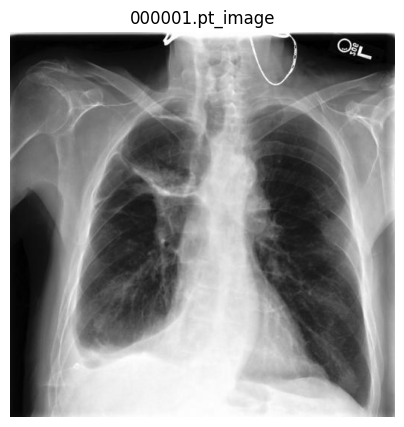

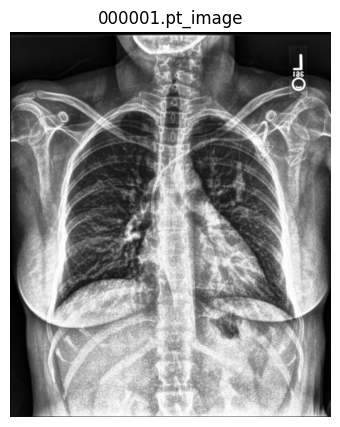

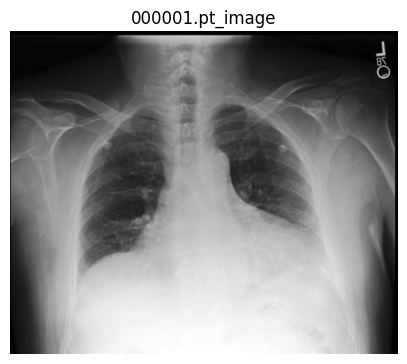

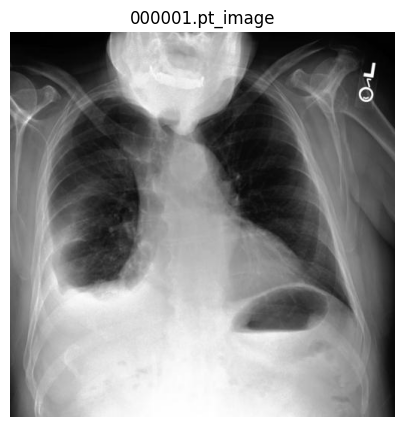

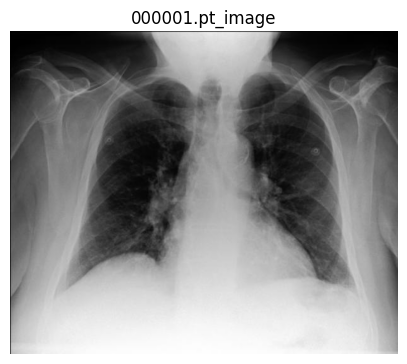

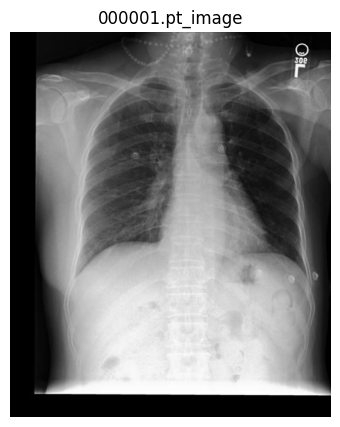

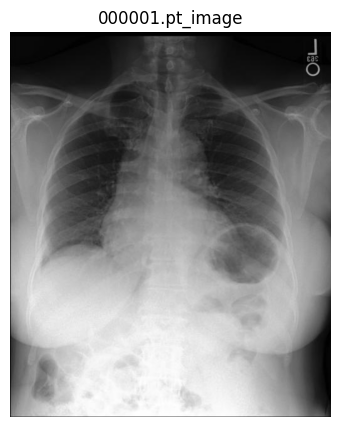

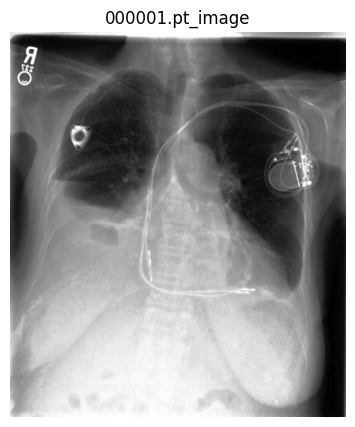

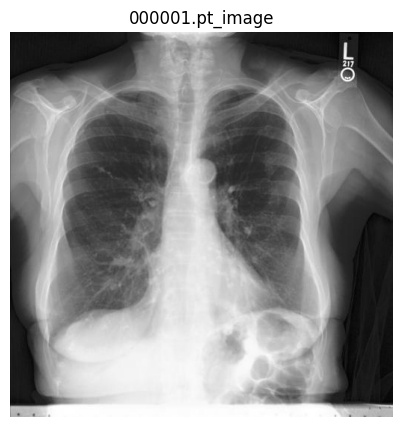

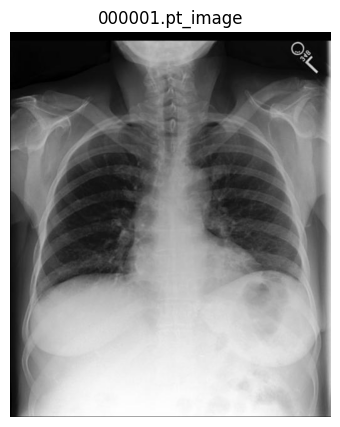

In [7]:
import tarfile

demo_tar_path = "/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/val_data/val_1.tar"

import io
from PIL import Image
import torch
import matplotlib.pyplot as plt
pics_to_show = 10
with tarfile.open(demo_tar_path, "r") as tar:
    # Find the member named "000001.pt_image"
    pt_img_member = None
    count = 0
    for member in tar.getmembers():
        if "image" in member.name and count < pics_to_show:
            fileobj = tar.extractfile(member)
            img_tensor = torch.load(fileobj)
            # img_tensor should be a tensor (C, H, W) or (H, W, C)
            if img_tensor.dim() == 3 and img_tensor.shape[0] in [1, 3]:
                # (C,H,W), convert to (H,W,C)
                image = img_tensor.permute(1, 2, 0).cpu().numpy()
            elif img_tensor.dim() == 3 and img_tensor.shape[2] in [1,3]:
                image = img_tensor.cpu().numpy()
            elif img_tensor.dim() == 2:
                image = img_tensor.cpu().numpy()
            else:
                raise ValueError(f"Unexpected image tensor shape: {img_tensor.shape}")

            plt.figure(figsize=(5,5))
            if image.ndim == 3 and image.shape[2] == 1:
                plt.imshow(image[:,:,0], cmap='gray')
            else:
                plt.imshow(image, cmap='gray' if image.ndim==2 else None)
            plt.title("000001.pt_image")
            plt.axis('off')
            plt.show()
            count += 1


In [ ]:
import tarfile

demo_tar_path = "/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data/mimiccxr_pa_sentence_webdataset.tar"

with tarfile.open(demo_tar_path, "r") as tar:
    print("Contents of", demo_tar_path)
    for member in tar.getmembers():
        print(member.name)


# Tokenizer

In [ ]:
# Tokenize impressions in PA_data using Stable Diffusion's tokenizer
from transformers import AutoTokenizer

# Choose the tokenizer consistent with training code (CLIP tokenizer from SD v1-4)
model_id = "stanfordmimi/RoentGen-v2"
try:
    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        subfolder="tokenizer",
        use_fast=True,
        trust_remote_code=True,
        token=token,
    )
except Exception:
    # Fallback to default loading if subfolder is not available
    tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True, trust_remote_code=True, token=token)

# Ensure PA_data exists and has an 'impression' column
assert 'PA_data' in globals(), "PA_data DataFrame not found in the notebook."
assert 'impression' in PA_data.columns, "PA_data is missing the 'impression' column."

# Prepare texts (handle NaNs)
texts = PA_data['impression'].fillna("").astype(str)

# Get tokenizer max length (defaults to 77 for CLIP)
if hasattr(tokenizer, 'model_max_length'):
    max_len = tokenizer.model_max_length
else:
    max_len = 77  # fallback CLIP default

# Batch tokenize for efficiency (with truncation and max_length)
encodings = tokenizer(
    texts.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_attention_mask=True,
)

# Store tokenized outputs as list columns
PA_data['input_ids'] = encodings['input_ids']
PA_data['attention_mask'] = encodings['attention_mask']

# Check for entries that exceeded the token limit BEFORE truncation (by re-tokenizing with no truncation)
lengths = [len(tokenizer.encode(t, add_special_tokens=True, truncation=False)) for t in texts]
PA_data['n_input_tokens'] = lengths
PA_data['truncated'] = PA_data['n_input_tokens'] > max_len

# Show stats about truncation
n_truncated = PA_data['truncated'].sum()
print(f"Number of samples truncated due to token limit ({max_len}): {n_truncated}")
if n_truncated > 0:
    print(PA_data.loc[PA_data['truncated'], ['impression', 'n_input_tokens']].head())

# Quick sanity check: show shapes/lengths of the first few entries
print("Tokenizer vocab size:", tokenizer.vocab_size)
print("Max length used:", max_len)
print("First input_ids length:", len(PA_data['input_ids'].iloc[0]) if len(PA_data) else None)


Token indices sequence length is longer than the specified maximum sequence length for this model (80 > 77). Running this sequence through the model will result in indexing errors


Number of samples truncated due to token limit (77): 3939
                                            impression  n_input_tokens
25   Compared to chest radiographs since ___, most ...              80
335  PA and lateral chest reviewed in the absence o...             123
574  Compared to chest radiographs ___ and chest CT...              91
709  Pacemaker leads terminate in right atrium and ...              89
744  PA and lateral chest compared to ___.\n \n Sli...              79
Tokenizer vocab size: 49408
Max length used: 77
First input_ids length: 77
